# 02 · Linear Regression

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/02-linear-regression/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · A tiny dataset: area vs. price

In [1]:
import numpy as np
import pandas as pd

area = np.array([50, 60, 70, 85, 100, 120, 140])          # square meters
price = np.array([540, 560, 780, 790, 1040, 1080, 1340])  # thousands of dollars

df = pd.DataFrame({"area": area, "price": price})
print(df)
#    area  price
# 0    50    540
# 1    60    560
# 2    70    780
# 3    85    790
# 4   100   1040
# 5   120   1080
# 6   140   1340

   area  price
0    50    540
1    60    560
2    70    780
3    85    790
4   100   1040
5   120   1080
6   140   1340


- Bigger homes cost more, roughly in proportion: a nearly linear relationship with a little real-world noise.
- The DataFrame is just for a tidy printout; the model works with the NumPy arrays underneath.

### Step 2 · Fit the model and read w and b

In [2]:
from sklearn.linear_model import LinearRegression

# scikit-learn always wants X as a 2-D table: (n_samples, n_features)
X = area.reshape(-1, 1)
y = price

model = LinearRegression()
model.fit(X, y)

print("w (coef_):", model.coef_)
print("b (intercept_):", model.intercept_)
# w (coef_): [8.756396]
# b (intercept_): 93.89321468298101

w (coef_): [8.756396]
b (intercept_): 93.89321468298101


- `reshape(-1, 1)` turns the 1-D array of shape `(7,)` into a 2-D table of shape `(7, 1)`: 7 rows, 1 feature. Forgetting it is the most common beginner error in scikit-learn.
- `model.fit(X, y)` is where learning happens: it finds the w and b with the lowest MSE.
- The model learned **price ≈ 8.76 × area + 93.9**: each extra m² adds about $8,760.

### Step 3 · Predict prices for new houses

In [3]:
new_areas = np.array([[90], [110], [200]])
predicted = model.predict(new_areas)

for a, p in zip(new_areas.flatten(), predicted):
    print(f"{a} m² -> ${p:,.0f}k")
# 90 m² -> $882k
# 110 m² -> $1,057k
# 200 m² -> $1,845k

90 m² -> $882k
110 m² -> $1,057k
200 m² -> $1,845k


- `new_areas` must be 2-D too: `predict` expects the same shape of input that `fit` saw.
- Careful with the 200 m² house. It's far outside the training range (50 to 140 m²), and predicting outside the data you've seen, called **extrapolation**, is always less trustworthy.

### Step 4 · How good is the fit?

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)

print("MSE:", round(mean_squared_error(y, y_pred), 1))
print("R²: ", round(r2_score(y, y_pred), 3))
print("model.score:", round(model.score(X, y), 3))
# MSE: 2973.1
# R²:  0.959
# model.score: 0.959

MSE: 2973.1
R²:  0.959
model.score: 0.959


- An R² of 0.959 means the line explains about 96% of the variation in price. Area alone predicts price very well here.
- For regression models, `model.score(X, y)` is a shortcut for R².
- We graded the model on the same houses it learned from, which flatters it. A fair grade uses data the model has **never seen**; you'll do that in the mini project, and lesson 08 is all about it.

### See it

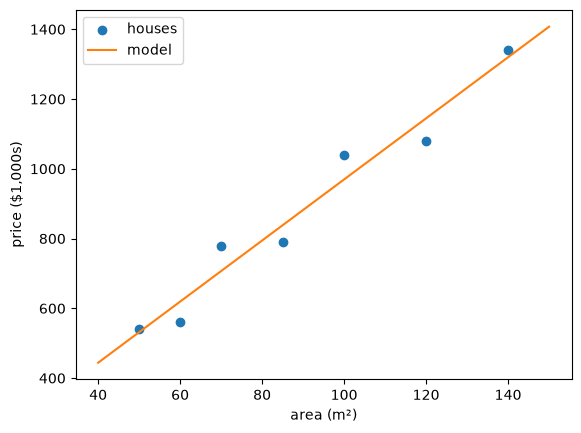

In [5]:
import matplotlib.pyplot as plt

xs = np.linspace(40, 150, 100).reshape(-1, 1)
plt.scatter(area, price, label="houses")
plt.plot(xs, model.predict(xs), color="tab:orange", label="model")
plt.xlabel("area (m²)")
plt.ylabel("price ($1,000s)")
plt.legend()
plt.show()

### Bonus · Gradient descent in 10 lines of NumPy

In [6]:
x = area / 100          # area in hundreds of m²: small numbers keep learning stable
w, b = 0.0, 0.0         # start with a flat line at zero
lr = 0.5                # learning rate: the size of each step

for step in range(1, 501):
    error = (w * x + b) - price          # how wrong is the line right now?
    w -= lr * 2 * np.mean(error * x)     # nudge w downhill
    b -= lr * 2 * np.mean(error)         # nudge b downhill
    if step in (1, 10, 100, 500):
        print(f"step {step:>3}:  w = {w / 100:5.2f}   b = {b:6.1f}   MSE = {np.mean(error ** 2):9,.0f}")
# step   1:  w =  8.62   b =  875.7   MSE =   840,186
# step  10:  w =  5.46   b =  245.3   MSE =    44,376
# step 100:  w =  8.73   b =   96.2   MSE =     2,974
# step 500:  w =  8.76   b =   93.9   MSE =     2,973

step   1:  w =  8.62   b =  875.7   MSE =   840,186
step  10:  w =  5.46   b =  245.3   MSE =    44,376
step 100:  w =  8.73   b =   96.2   MSE =     2,974
step 500:  w =  8.76   b =   93.9   MSE =     2,973


- `2 * np.mean(error * x)` and `2 * np.mean(error)` are the slopes of the MSE valley with respect to w and b. That's the gradient.
- The loss drops from 840,186 to 2,973, and w and b land on the exact values scikit-learn found.
- Try `lr = 2.0`: the steps are too big, the model jumps over the valley, and the loss explodes. Picking a good learning rate matters.